In [2]:
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from scipy.spatial.distance import pdist, squareform
from nilearn.image import resample_to_img

base_dir = Path(r"D:\NTU_PSY\Documents\Patric_Asen_BrainHackProject")



##讀取特定subject的特定concepts trial index

def load_and_filter_conditions(
    base_dir,
    sub_id,
    targets,
    filename="subject_fMRI_nii/sub-01_condition_with_ratings.csv",
    verbose=True
):
    """
    Load + filter + sort fMRI condition table
    """

    # -------------------------
    # 1. load data
    # -------------------------
    path = base_dir / filename.replace("sub-01", sub_id)
    df = pd.read_csv(path)

    # -------------------------
    # 2. filter concepts
    # -------------------------
    df_selected = df[df["concept"].isin(targets)].copy()

    # -------------------------
    # 3. ordering
    # -------------------------
    df_selected["concept"] = pd.Categorical(
        df_selected["concept"],
        categories=targets,
        ordered=True
    )

    df_selected = (
        df_selected
        .sort_values(by=["concept"])
        .reset_index(drop=True)
    )

    # -------------------------
    # 4. print (optional)
    # -------------------------
    if verbose:
        print(f"\n[{sub_id}] total selected:", len(df_selected))
        print(df_selected["concept"].value_counts())
        print(df_selected)

    return df_selected



##由篩選過的trial index讀取部分concepts的fMRI trial

def extract_fmri_volumes_rowwise(
    df_sorted,
    base_dir,
    sub_id="sub-01",
    verbose=True
):
    """
    Extract fMRI volumes strictly following df row order.

    Returns
    -------
    selected_volumes : np.ndarray
        shape = (x, y, z, n_trials)
    concept_labels : np.ndarray
        shape = (n_trials,)
    """

    selected_volumes = []
    concept_labels = []

    for row in df_sorted.itertuples():

        img_path = (
            base_dir /
            "subject_fMRI_nii" /
            sub_id /
            row.session /
            f"{sub_id}_{row.session}_run-{row.run:02d}_betas.nii"
        )

        img = nib.load(img_path)
        data = img.get_fdata()

        t = int(row.trial_idx)
        vol = data[..., t]

        selected_volumes.append(vol)
        concept_labels.append(row.concept)

    selected_volumes = np.stack(selected_volumes, axis=-1)

    if verbose:
        print("Final shape:", selected_volumes.shape)
        print("mean:", np.mean(selected_volumes))
        print("std:", np.std(selected_volumes))
        print("min:", np.min(selected_volumes))
        print("max:", np.max(selected_volumes))

    return selected_volumes, np.array(concept_labels)







##讀取並轉換atlas

reference_img = nib.load(base_dir / "subject_fMRI_nii\sub-01\ses-things01\sub-01_ses-things01_run-01_betas.nii")

atlas_img = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz")
atlas = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz").get_fdata()
print(atlas.shape)
print(atlas_img.affine)

##對atlas進行線性轉換，符合fMRI結構
print("beta shape:\n", reference_img.shape)
print("atlas shape:\n", atlas_img.shape)

print("beta affine:\n", reference_img.affine)
print("atlas affine:\n", atlas_img.affine)


atlas_rs = resample_to_img(atlas_img, reference_img, interpolation="nearest")
atlas = atlas_rs.get_fdata()

print("===resampled atlas info===")
print("resampled atlas shape:\n", atlas_rs.shape)
print("resampled atlas affine:\n", atlas_rs.affine)

##讀取atlas region名稱
tree = ET.parse(base_dir / "HCP_atlas\HCP-Multi-Modal-Parcellation-1.0.xml")
root = tree.getroot()

labels = {}

for label in root.find("data").findall("label"):
    idx = int(label.attrib["index"])
    name = label.text.strip()
    if name != "*.*.*.*.*":
        labels[idx] = name

print(labels)

df_labels = pd.DataFrame.from_dict(
    labels,
    orient="index",
    columns=["name"]
).reset_index().rename(columns={"index": "roi_id"})

def parse_name(name):
    try:
        hemi, region = name.split("_", 1)
        return hemi, region
    except:
        return None, name

df_labels[["hemi", "region"]] = df_labels["name"].apply(
    lambda x: pd.Series(parse_name(x))
)
print(df_labels.head())



##找尋特定roi id
def search_roi(df_labels, keyword):
    result = df_labels[
        df_labels["name"].str.contains(keyword, case=False, na=False)
    ].copy()

    return result.sort_values("roi_id")



##由已有的fMRI影像繪製特定roi的RDM

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def compute_roi_rdm(
    atlas,
    selected_volumes,
    roi_ids,
    concept_labels,
    title="ROI RDM",
    metric="correlation",
    plot=True,
    mode="image"   # "image" or "concept"
):

    roi_mask = np.isin(atlas, roi_ids)
    roi_data = selected_volumes[roi_mask]
    trial_pattern = roi_data.T   # (trials, voxels)

    # =========================
    # IMAGE-BASED RDM (96 × 96)
    # =========================
    if mode == "image":

        rdm = squareform(
            pdist(trial_pattern, metric=metric)
        )

        n_concepts = 8
        n_per_concept = 12

    # =========================
    # CONCEPT-BASED RDM (8 × 8)
    # =========================
    elif mode == "concept":

        unique_concepts = list(dict.fromkeys(concept_labels))

        concept_patterns = []

        for c in unique_concepts:
            idx = np.where(np.array(concept_labels) == c)[0]
            concept_patterns.append(trial_pattern[idx].mean(axis=0))

        concept_patterns = np.vstack(concept_patterns)

        rdm = squareform(
            pdist(concept_patterns, metric=metric)
        )

    else:
        raise ValueError("mode must be 'image' or 'concept'")

    # =========================
    # PLOT
    # =========================
    if plot:

        fig, ax = plt.subplots(figsize=(7, 7))
        im = ax.imshow(rdm, interpolation="none")
        ax.set_title(title)

        # =========================
        # IMAGE LABELING (block-wise)
        # =========================
        if mode == "image":

            ticks = np.arange(0, n_concepts * n_per_concept, n_per_concept)
            labels = [concept_labels[t] for t in ticks]

            ax.set_xticks(ticks)
            ax.set_yticks(ticks)

            ax.set_xticklabels(labels, rotation=45)
            ax.set_yticklabels(labels)


        # =========================
        # CONCEPT LABELING (8×8)
        # =========================
        elif mode == "concept":

            n_concepts = rdm.shape[0]
            labels = unique_concepts

            ax.set_xticks(np.arange(n_concepts))
            ax.set_yticks(np.arange(n_concepts))

            ax.set_xticklabels(labels, rotation=45)
            ax.set_yticklabels(labels)

        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()

    return roi_mask, rdm

(256, 256, 256)
[[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
beta shape:
 (72, 91, 75, 92)
atlas shape:
 (256, 256, 256)
beta affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
atlas affine:
 [[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
===resampled atlas info===
resampled atlas shape:
 (72, 91, 75)
resampled atlas affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
{1: 'L_V1', 2: 'L_MST', 3: 'L_V6', 4: 'L_V2', 5: 'L_V3', 6: 'L_V4', 7: 'L_V8', 8: 'L_4', 9: 'L_3b', 10: 'L_FEF', 11: 'L_PEF', 12: 'L_55b', 13: 'L_

In [49]:
from pathlib import Path

folder = Path(base_dir / "affordance candidate")

affordance_candidates = [
    p.stem for p in folder.iterdir()
    if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
]

print(affordance_candidates)

affordance_candidates_list = affordance_candidates

['broom', 'brush', 'calculator', 'comb', 'corkscrew', 'crowbar', 'crutch', 'dustpan', 'flyswatter', 'gearshift', 'glass', 'grenade', 'hairbrush', 'hammer', 'jar', 'joystick', 'knife', 'magnifying_glass', 'match', 'needle', 'pencil', 'phone', 'ruler', 'scissors', 'screwdriver', 'shovel', 'silverware', 'spatula', 'spoon', 'squeegee', 'sword', 'tongs', 'trowel', 'tweezers', 'typewriter']


In [ ]:
##affordance_candidates_list = ['calculator', 'typewriter', 'pencil', 'spoon', 'tongs', 'tweezers', 'gearshift', 'joystick']
##concepts_label = affordance_candidates_list
    

In [48]:
df_sub01 = load_and_filter_conditions(
    base_dir=base_dir,
    sub_id="sub-01",
    targets=affordance_candidates_list
)


[sub-01] total selected: 420
concept
broom               12
brush               12
calculator          12
comb                12
corkscrew           12
crowbar             12
crutch              12
dustpan             12
flyswatter          12
gearshift           12
glass               12
grenade             12
hairbrush           12
hammer              12
jar                 12
joystick            12
knife               12
magnifying_glass    12
match               12
needle              12
pencil              12
phone               12
ruler               12
scissors            12
screwdriver         12
shovel              12
silverware          12
spatula             12
spoon               12
squeegee            12
sword               12
tongs               12
trowel              12
tweezers            12
typewriter          12
Name: count, dtype: int64
                    image_filename       session  run  trial_idx subject  \
0              broom/broom_01b.jpg  ses-things03    4  

In [50]:
selected_volumes, concept_labels = extract_fmri_volumes_rowwise(
    df_sorted=df_sub01,
    base_dir=base_dir,
    sub_id="sub-01"
)

Final shape: (72, 91, 75, 420)
mean: 0.0005852172062258446
std: 0.041826667434984324
min: -0.6456673741340637
max: 0.7676836848258972


# Affordance ROI

In [51]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


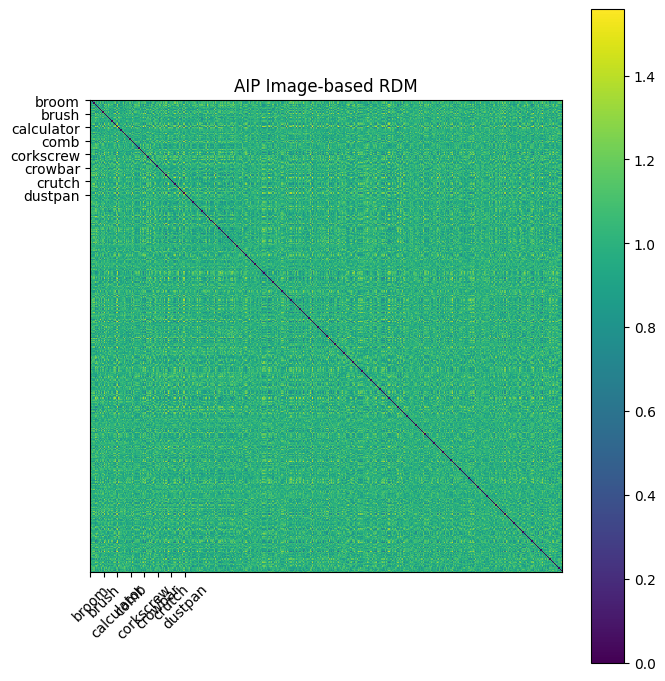

In [80]:
AIP_ids = [
    117, 1117
]

_, AIP_rdm_img = compute_roi_rdm(
    atlas,
    selected_volumes,
    AIP_ids,
    concept_labels,
    title="AIP Image-based RDM",
    mode="image"
)

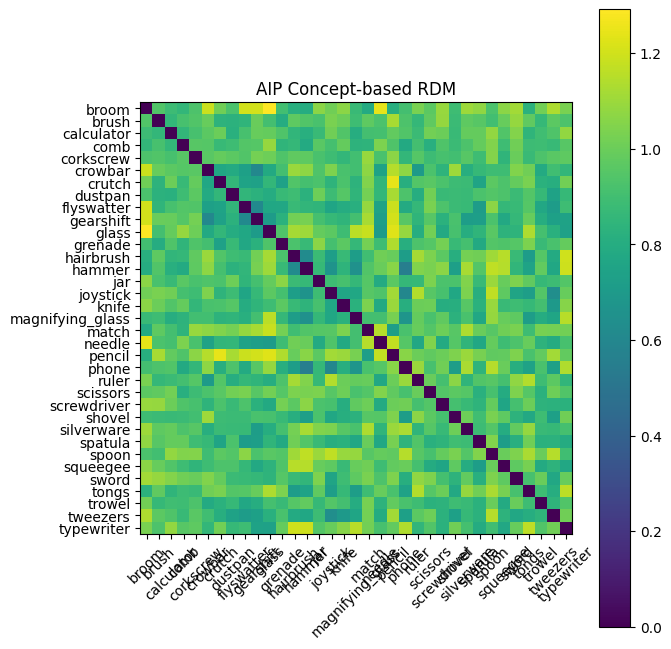

In [53]:
_, AIP_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    AIP_ids,
    concept_labels,
    title="AIP Concept-based RDM",
    mode="concept"
)

In [54]:
search_roi(df_labels, "PF")

,roi_id,name,hemi,region
104,105,L_PFcm,L,PFcm
115,116,L_PFt,L,PFt
146,147,L_PFop,L,PFop
147,148,L_PF,L,PF
148,149,L_PFm,L,PFm
284,1105,R_PFcm,R,PFcm
295,1116,R_PFt,R,PFt
326,1147,R_PFop,R,PFop
327,1148,R_PF,R,PF
328,1149,R_PFm,R,PFm


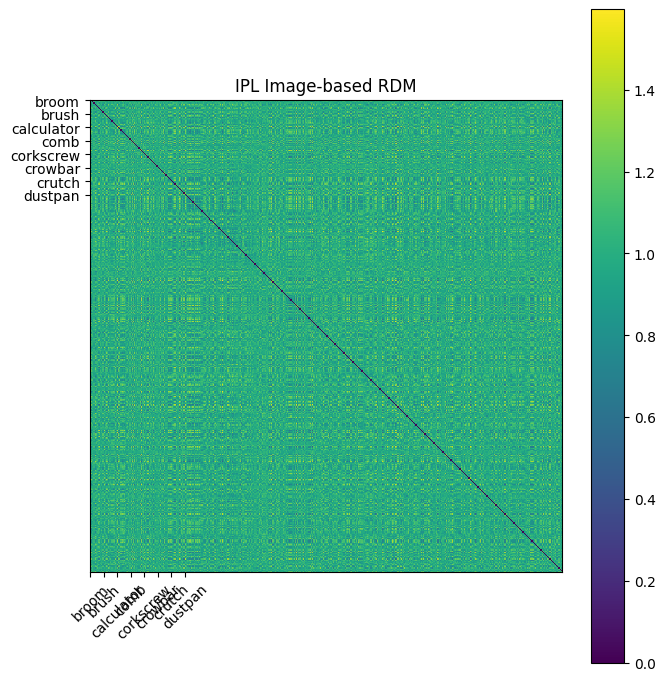

In [55]:
IPL_ids = [
    105, 116, 147, 148, 149
]

_, IPL_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    IPL_ids,
    concept_labels,
    title="IPL Image-based RDM",
    mode="image"
)

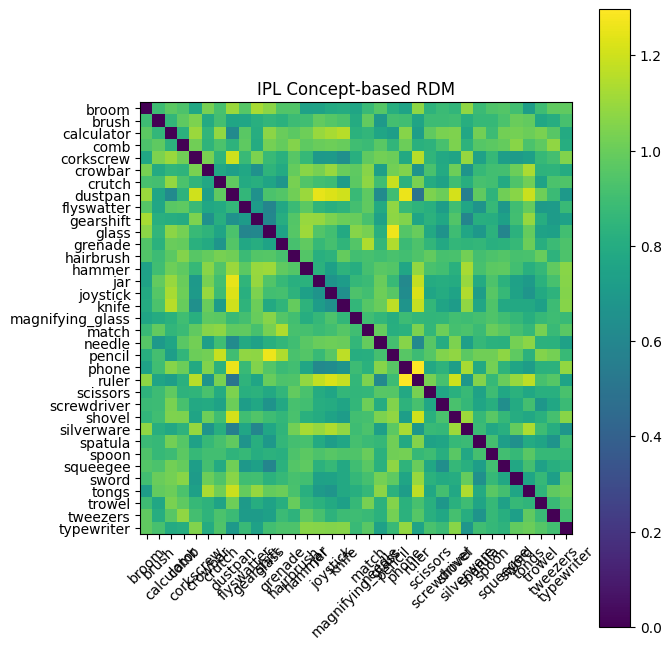

In [56]:
_, IPL_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    IPL_ids,
    concept_labels,
    title="IPL Concept-based RDM",
    mode="concept"
)

In [57]:
search_roi(df_labels, "6V")

,roi_id,name,hemi,region
55,56,L_6v,L,6v
82,83,L_p9-46v,L,p9-46v
84,85,L_a9-46v,L,a9-46v
235,1056,R_6v,R,6v
262,1083,R_p9-46v,R,p9-46v
264,1085,R_a9-46v,R,a9-46v


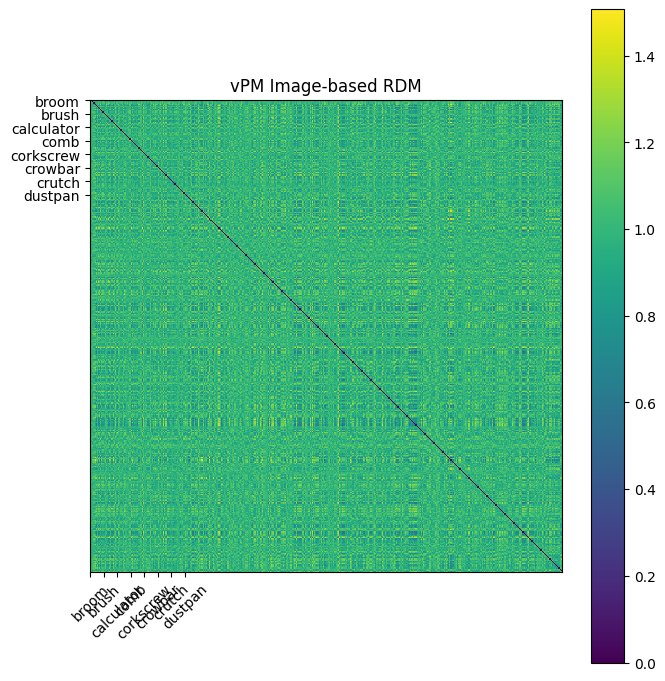

In [58]:
vPM_ids = [
    56, 1056
]

_, vPM_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    vPM_ids,
    concept_labels,
    title="vPM Image-based RDM",
    mode="image"
)

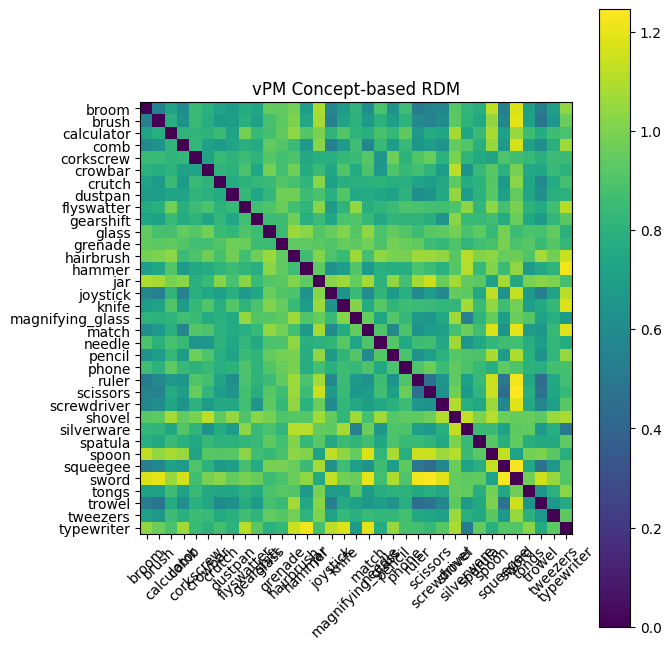

In [59]:
_, vPM_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    vPM_ids,
    concept_labels,
    title="vPM Concept-based RDM",
    mode="concept"
)

# Object/Semantic ROI

In [60]:
search_roi(df_labels, "LO")

,roi_id,name,hemi,region
19,20,L_LO1,L,LO1
20,21,L_LO2,L,LO2
158,159,L_LO3,L,LO3
199,1020,R_LO1,R,LO1
200,1021,R_LO2,R,LO2
338,1159,R_LO3,R,LO3


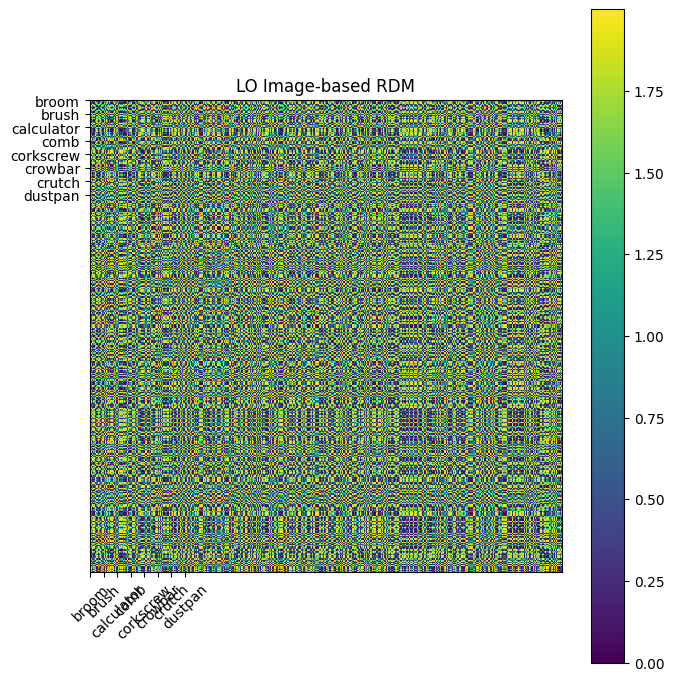

In [94]:
LO_ids = [
    1159
]

_, LO_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    LO_ids,
    concept_labels,
    title="LO Image-based RDM",
    mode="image"
)

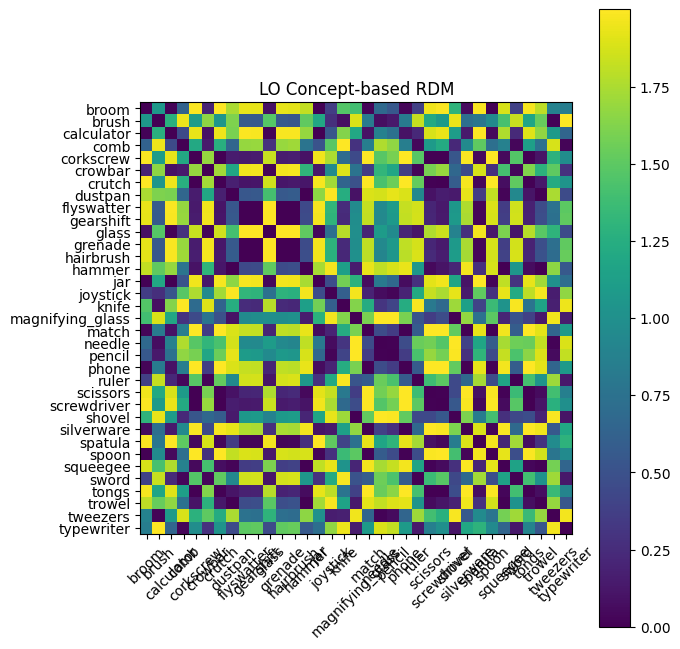

In [62]:
_, LO_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    LO_ids,
    concept_labels,
    title="LO Concept-based RDM",
    mode="concept"
)

In [99]:
search_roi(df_labels, "PIT")

,roi_id,name,hemi,region
21,22,L_PIT,L,PIT
201,1022,R_PIT,R,PIT


In [101]:
# 檢查 A：看看這個腦區到底有沒有抓到任何 Voxel
# 假設你的 atlas 是一個 numpy 陣列，檢查裡面有沒有這兩個 ID
voxel_count_L = np.sum(atlas == 22)
voxel_count_R = np.sum(atlas == 1022)
print(f"左腦 PIT 包含的 Voxel 數量: {voxel_count_L}")
print(f"右腦 PIT 包含的 Voxel 數量: {voxel_count_R}")

# 檢查 B：看看算出來的 RDM 矩陣是不是真的都是 NaN
print("PIT RDM 矩陣前 5x5 的數值：")
print(PIT_rdm_concept[:5, :5])

左腦 PIT 包含的 Voxel 數量: 58
右腦 PIT 包含的 Voxel 數量: 83
PIT RDM 矩陣前 5x5 的數值：
[[ 0. nan nan nan nan]
 [nan  0. nan nan nan]
 [nan nan  0. nan nan]
 [nan nan nan  0. nan]
 [nan nan nan nan  0.]]


已成功清除 selected_volumes 中的所有 NaN！


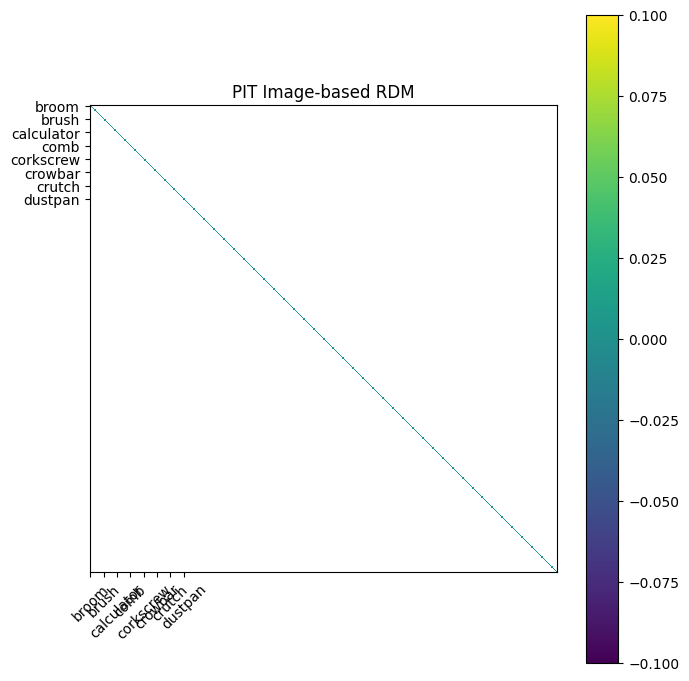

In [103]:
if isinstance(selected_volumes, np.ndarray):
    selected_volumes = np.nan_to_num(selected_volumes, nan=0.0)
    print("已成功清除 selected_volumes 中的所有 NaN！")
    
PIT_ids = [
    22, 1022
]
_, PIT_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    PIT_ids,
    concept_labels,
    title="PIT Image-based RDM",
    mode="image"
)


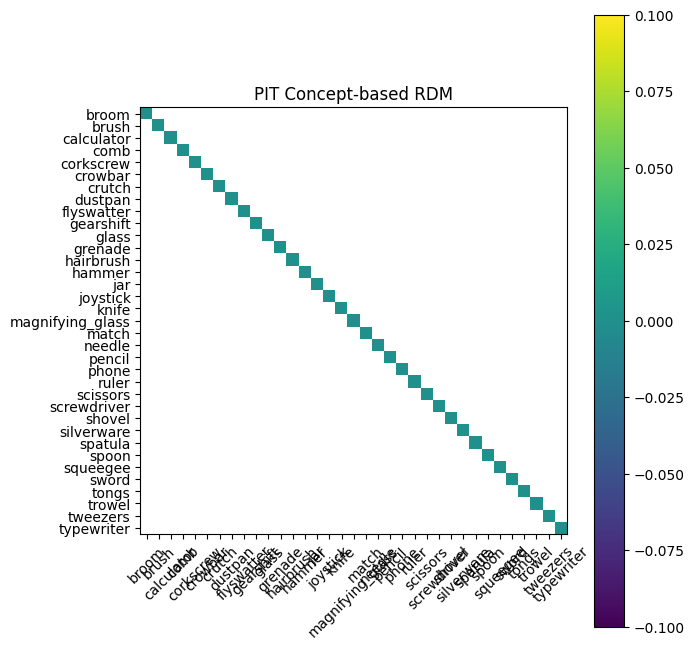

In [104]:
_, PIT_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    PIT_ids,
    concept_labels,
    title="PIT Concept-based RDM",
    mode="concept"
)

In [63]:
search_roi(df_labels, "FFC")

,roi_id,name,hemi,region
17,18,L_FFC,L,FFC
197,1018,R_FFC,R,FFC


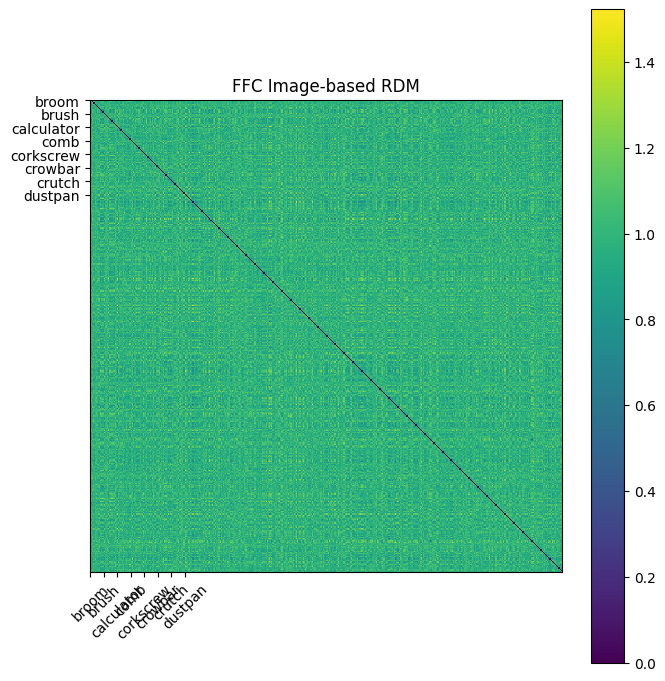

In [64]:
FFC_ids = [
    18, 1018
]
_, FFC_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    FFC_ids,
    concept_labels,
    title="FFC Image-based RDM",
    mode="image"
)


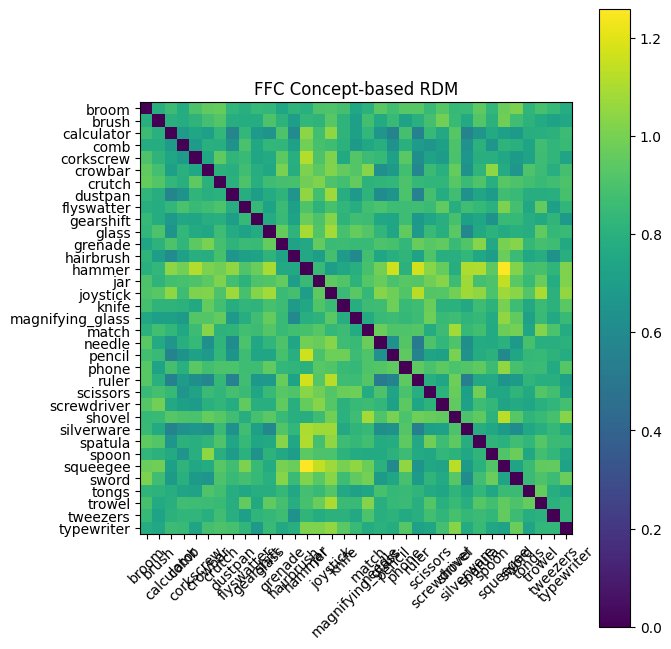

In [65]:
_, FFC_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    FFC_ids,
    concept_labels,
    title="FFC Concept-based RDM",
    mode="concept"
)

In [66]:
search_roi(df_labels, "VVC")

,roi_id,name,hemi,region
162,163,L_VVC,L,VVC
342,1163,R_VVC,R,VVC


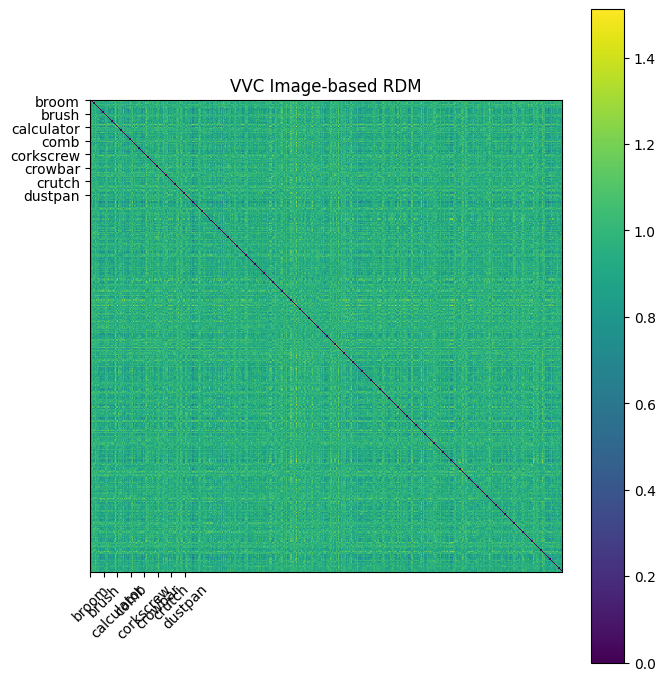

In [67]:
VVC_ids = [
    163, 1163
]
_, VVC_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VVC_ids,
    concept_labels,
    title="VVC Image-based RDM",
    mode="image"
)


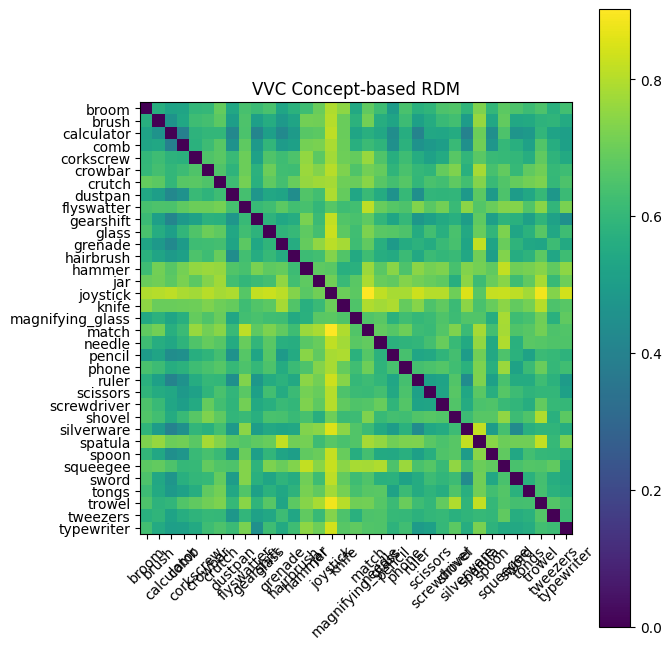

In [68]:
_, VVC_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VVC_ids,
    concept_labels,
    title="VVC Concept-based RDM",
    mode="concept"
)

In [69]:
search_roi(df_labels, "VMV1")

,roi_id,name,hemi,region
152,153,L_VMV1,L,VMV1
332,1153,R_VMV1,R,VMV1


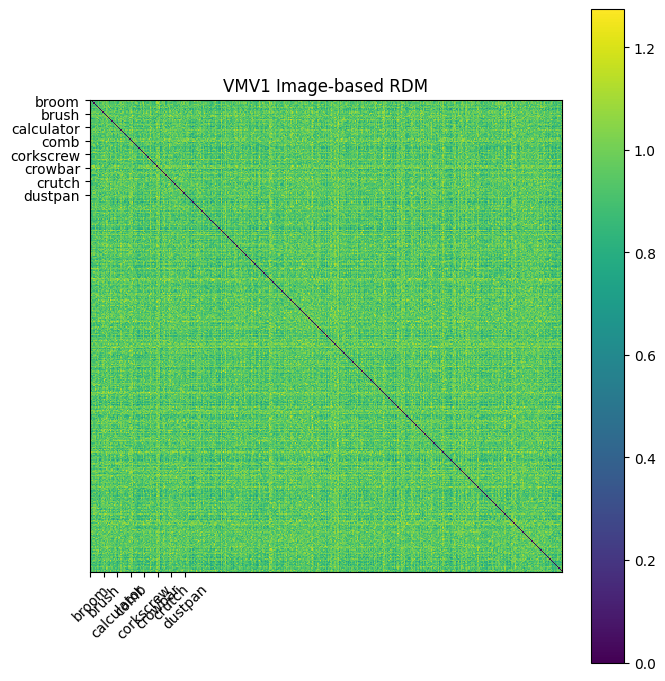

In [79]:
VMV1_ids = [
    153, 1153
]
_, VMV1_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV1_ids,
    concept_labels,
    title="VMV1 Image-based RDM",
    mode="image"
)


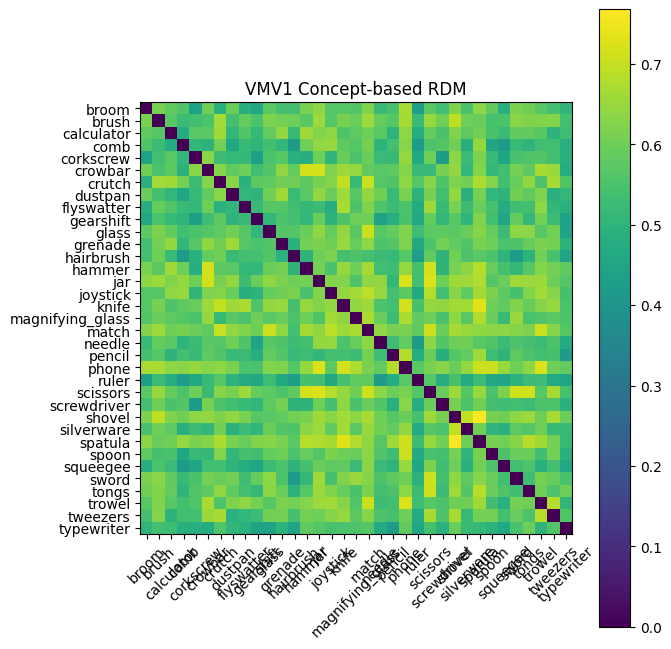

In [71]:
_, VMV1_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV1_ids,
    concept_labels,
    title="VMV1 Concept-based RDM",
    mode="concept"
)

In [72]:
search_roi(df_labels, "VMV2")

,roi_id,name,hemi,region
159,160,L_VMV2,L,VMV2
339,1160,R_VMV2,R,VMV2


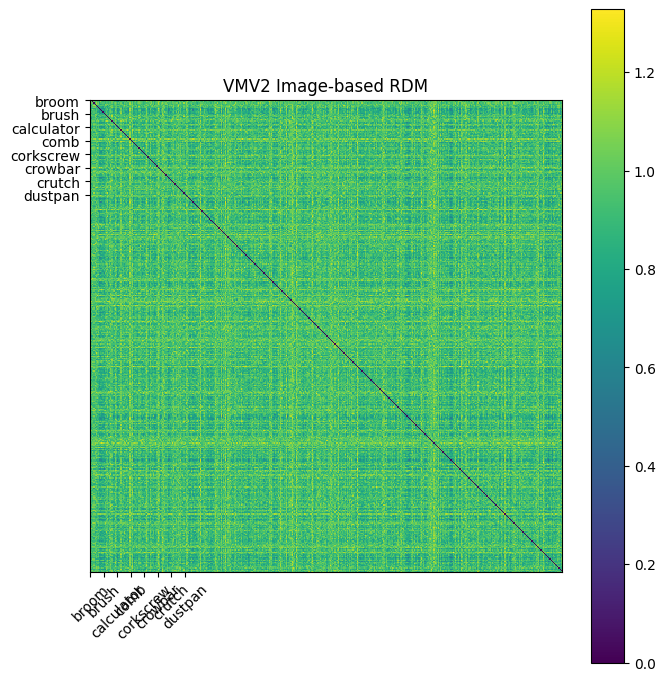

In [73]:
VMV2_ids = [
    160, 1160
]
_, VMV2_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV2_ids,
    concept_labels,
    title="VMV2 Image-based RDM",
    mode="image"
)

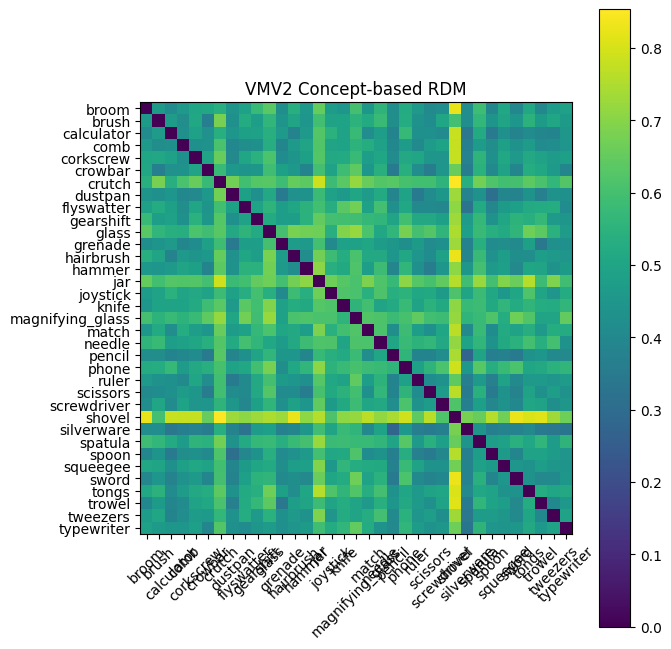

In [74]:
_, VMV2_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV2_ids,
    concept_labels,
    title="VMV2 Concept-based RDM",
    mode="concept"
)

In [75]:
search_roi(df_labels, "VMV3")

,roi_id,name,hemi,region
153,154,L_VMV3,L,VMV3
333,1154,R_VMV3,R,VMV3


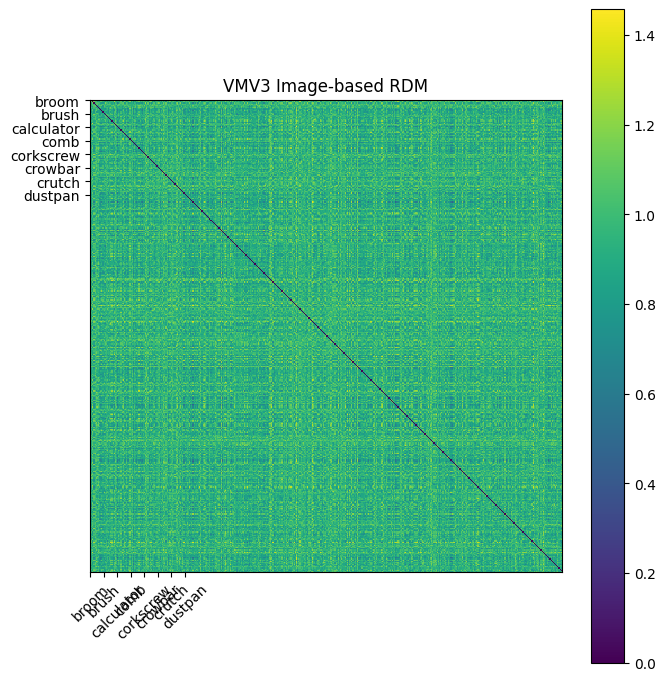

In [76]:
VMV3_ids = [
    154, 1154
]
_, VMV3_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV3_ids,
    concept_labels,
    title="VMV3 Image-based RDM",
    mode="image"
)

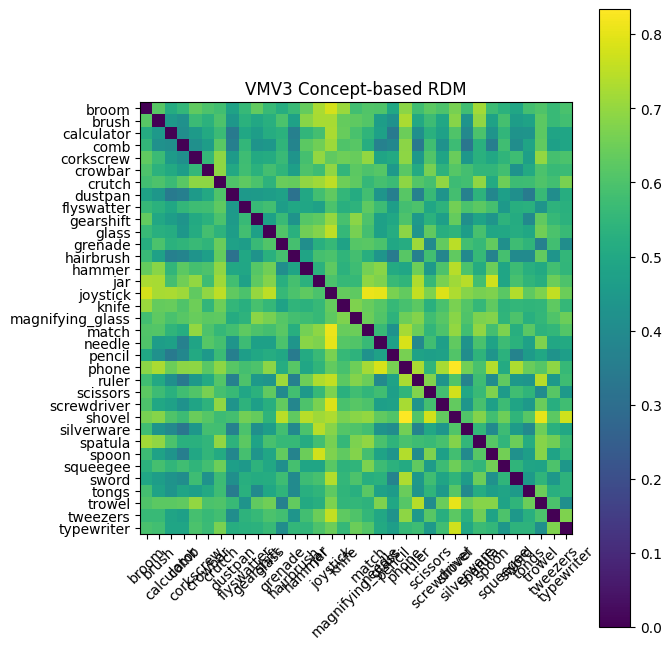

In [77]:
_, VMV3_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    VMV3_ids,
    concept_labels,
    title="VMV3 Concept-based RDM",
    mode="concept"
)

## RSA

================= 跨群組 RSA 分析開始 =================

[VVC vs AIP]
  Spearman rho: 0.0472 (p = 0.2498)
  Pearson r   : 0.0501 (p = 0.2219)
--------------------------------------------------


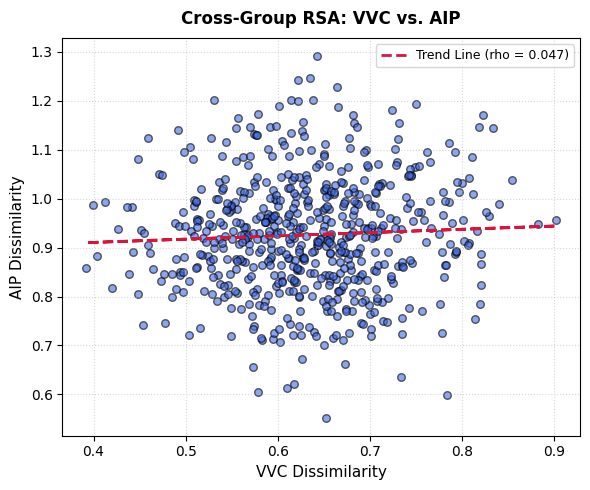

[VVC vs IPL]
  Spearman rho: 0.0409 (p = 0.3188)
  Pearson r   : 0.0787 (p = 0.05505)
--------------------------------------------------


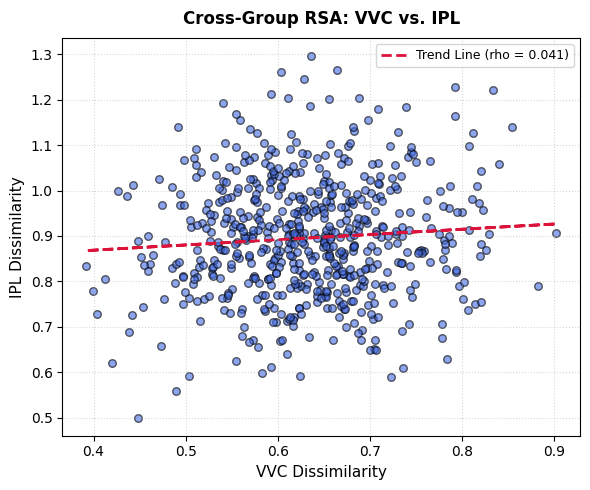

[VVC vs vPM]
  Spearman rho: 0.0012 (p = 0.9775)
  Pearson r   : -0.0047 (p = 0.9099)
--------------------------------------------------


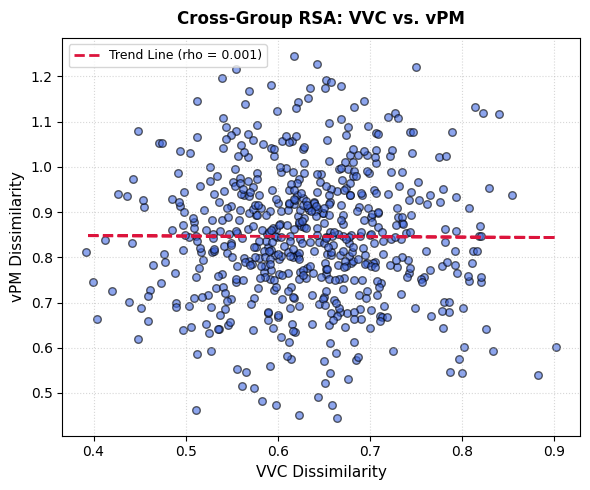

[FFC vs AIP]
  Spearman rho: 0.1835 (p = 6.651e-06)
  Pearson r   : 0.1897 (p = 3.153e-06)
--------------------------------------------------


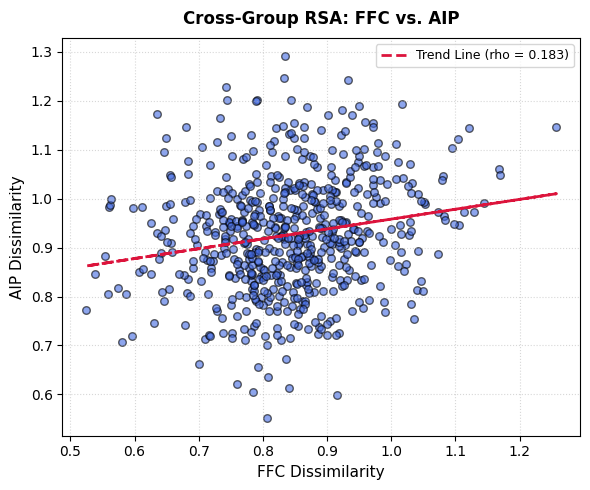

[FFC vs IPL]
  Spearman rho: 0.1207 (p = 0.003189)
  Pearson r   : 0.1817 (p = 8.214e-06)
--------------------------------------------------


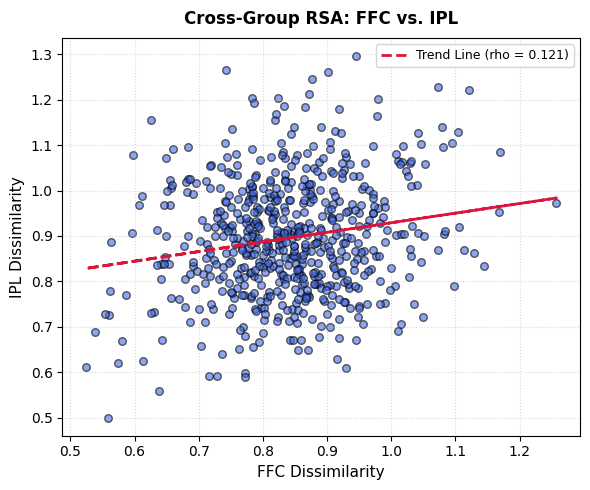

[FFC vs vPM]
  Spearman rho: 0.0685 (p = 0.09529)
  Pearson r   : 0.0733 (p = 0.07417)
--------------------------------------------------


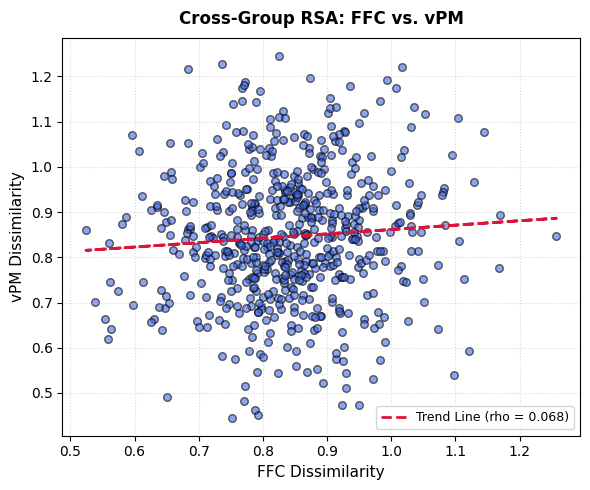

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
import itertools

# ====================================================
# 【步驟 1】核心 RSA 分析與繪圖函式（維持不變）
# ====================================================
def run_rsa_pair(name1, rdm1, name2, rdm2, show_plot=True):
    vec1 = squareform(rdm1)
    vec2 = squareform(rdm2)
    
    spearman_corr, spearman_p = stats.spearmanr(vec1, vec2)
    pearson_corr, pearson_p = stats.pearsonr(vec1, vec2)
    
    print(f"[{name1} vs {name2}]")
    print(f"  Spearman rho: {spearman_corr:.4f} (p = {spearman_p:.4g})")
    print(f"  Pearson r   : {pearson_corr:.4f} (p = {pearson_p:.4g})")
    print("-" * 50)
    
    if show_plot:
        plt.figure(figsize=(6, 5))
        plt.scatter(vec1, vec2, color='royalblue', alpha=0.6, edgecolors='k', s=30)
        
        m, b = np.polyfit(vec1, vec2, 1)
        plt.plot(vec1, m * vec1 + b, color='crimson', linestyle='--', linewidth=2,
                 label=f'Trend Line (rho = {spearman_corr:.3f})')
        
        plt.title(f"Cross-Group RSA: {name1} vs. {name2}", fontsize=12, fontweight='bold', pad=10)
        plt.xlabel(f"{name1} Dissimilarity", fontsize=11)
        plt.ylabel(f"{name2} Dissimilarity", fontsize=11)
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()
        
    return spearman_corr, spearman_p


# ====================================================
# 【步驟 2】將腦區明確分類為 A、B 兩大群組
# ====================================================
# 群組 A（例如：腹側視覺流腦區）
group_A = {
    "VVC": VVC_rdm_concept,
    
}

# 群組 B（例如：頂側運動/注意區）
group_B = {
    "AIP": AIP_rdm_concept,
    "IPL": IPL_rdm_concept,
    "vPM": vPM_rdm_concept,


    # "FEF": FEF_rdm_concept, <-- 之後有新腦區直接加進對應分類即可
}


# ====================================================
# 【步驟 3】跨群組自動化交叉分析 (A 的所有成員 vs B 的所有成員)
# ====================================================
print("================= 跨群組 RSA 分析開始 =================\n")

# itertools.product 會完美配對 A 與 B，且不包含 A-A 或 B-B
for name1, name2 in itertools.product(group_A.keys(), group_B.keys()):
    rdm1 = group_A[name1]
    rdm2 = group_B[name2]
    
    # 執行 RSA
    run_rsa_pair(name1, rdm1, name2, rdm2, show_plot=True)

print("======================================================")